# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The SPECTRA Oil and Gas Gas Trubine Dataset](https://www.kaggle.com/datasets/javierfalcondale/spectra-oil-and-gas-quantum-ready-gas-turbine-data/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/javierfalcondale/spectra-oil-and-gas-quantum-ready-gas-turbine-data/spectra_oilgas_gasturbine.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('spectra_oilgas_gasturbine.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,year,at_phase,ap_phase,ah_phase,afdp_phase,gtep_phase,in_pocket,target_real,target
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,2011,-2.95418,1.97647,0.531102,-1.08294,-1.05797,0,0,0
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,2011,-3.00261,1.90739,0.660032,-1.08968,-1.08917,0,0,0
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,2011,-3.00462,1.91708,0.742413,-1.06492,-1.03783,0,0,0
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,2011,-3.01248,1.87879,0.836349,-1.09033,-1.13437,0,0,0
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,2011,-3.06237,1.79132,0.775166,-1.05560,-1.10065,0,0,0


## last Five row

In [4]:
df.tail()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,year,at_phase,ap_phase,ah_phase,afdp_phase,gtep_phase,in_pocket,target_real,target
36728,3.6268,1028.5,93.200,3.1661,19.087,1037.0,541.59,109.08,10.411,2015,-3.01404,3.00631,2.25963,-2.019340,-2.93938,0,1,1
36729,4.1674,1028.6,94.036,3.1923,19.016,1037.6,542.28,108.79,10.344,2015,-2.96838,3.06303,2.41485,-1.962830,-2.96744,0,1,1
36730,5.4820,1028.5,95.219,3.3128,18.857,1038.0,543.48,107.81,10.462,2015,-2.86639,3.04463,2.57117,-1.652210,-3.03449,0,1,1
36731,5.8837,1028.7,94.200,3.9831,23.563,1076.9,550.11,131.41,11.771,2015,-2.80543,3.02609,2.44077,0.127774,-1.40881,0,0,0
36732,6.0392,1028.8,94.547,3.8752,22.524,1067.9,548.23,125.41,11.462,2015,-2.77389,3.06443,2.48483,-0.206501,-1.74095,0,1,1


## Shape of our dataset

In [5]:
df.shape

(36733, 18)

## List out all columns

In [6]:
df.columns

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'year',
       'at_phase', 'ap_phase', 'ah_phase', 'afdp_phase', 'gtep_phase',
       'in_pocket', 'target_real', 'target'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

AT             float64
AP             float64
AH             float64
AFDP           float64
GTEP           float64
TIT            float64
TAT            float64
TEY            float64
CDP            float64
year             int64
at_phase       float64
ap_phase       float64
ah_phase       float64
afdp_phase     float64
gtep_phase     float64
in_pocket        int64
target_real      int64
target           int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36733 entries, 0 to 36732
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AT           36733 non-null  float64
 1   AP           36733 non-null  float64
 2   AH           36733 non-null  float64
 3   AFDP         36733 non-null  float64
 4   GTEP         36733 non-null  float64
 5   TIT          36733 non-null  float64
 6   TAT          36733 non-null  float64
 7   TEY          36733 non-null  float64
 8   CDP          36733 non-null  float64
 9   year         36733 non-null  int64  
 10  at_phase     36733 non-null  float64
 11  ap_phase     36733 non-null  float64
 12  ah_phase     36733 non-null  float64
 13  afdp_phase   36733 non-null  float64
 14  gtep_phase   36733 non-null  float64
 15  in_pocket    36733 non-null  int64  
 16  target_real  36733 non-null  int64  
 17  target       36733 non-null  int64  
dtypes: float64(14), int64(4)
memory usage: 5.0 MB


## Check Null Value

In [9]:
df.isnull().sum()

AT             0
AP             0
AH             0
AFDP           0
GTEP           0
TIT            0
TAT            0
TEY            0
CDP            0
year           0
at_phase       0
ap_phase       0
ah_phase       0
afdp_phase     0
gtep_phase     0
in_pocket      0
target_real    0
target         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,year,at_phase,ap_phase,ah_phase,afdp_phase,gtep_phase,in_pocket,target_real,target
count,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000
mean,17.712726,1013.070165,77.867015,3.925518,25.563801,1081.428084,546.158517,133.506404,12.060525,2012.985735,0.000161,0.000010,0.000050,-0.000087,-0.000027,0.180002,0.200011,0.279041
std,7.447451,6.463346,14.461355,0.773936,4.195957,17.536373,6.842360,15.618634,1.088795,1.418965,1.813861,1.813872,1.813800,1.813875,1.813647,0.384194,0.400014,0.448534
min,-6.234800,985.850000,24.085000,2.087400,17.698000,1000.800000,511.040000,100.020000,9.851800,2011.000000,-3.141590,-3.141590,-3.141590,-3.141590,-3.141590,0.000000,0.000000,0.000000
25%,11.781000,1008.800000,68.188000,3.355600,23.129000,1071.800000,544.720000,124.450000,11.435000,2012.000000,-1.567410,-1.570970,-1.571390,-1.572050,-1.569800,0.000000,0.000000,0.000000
50%,17.801000,1012.600000,80.470000,3.937700,25.104000,1085.900000,549.880000,133.730000,11.965000,2013.000000,0.002283,-0.002575,-0.001907,0.000699,-0.000271,0.000000,0.000000,0.000000
75%,23.665000,1017.000000,89.376000,4.376900,29.061000,1097.000000,550.040000,144.080000,12.855000,2014.000000,1.571010,1.569540,1.569960,1.570420,1.570570,0.000000,0.000000,1.000000
max,37.103000,1036.600000,100.200000,7.610600,40.716000,1100.900000,550.610000,179.500000,15.159000,2015.000000,3.141590,3.141590,3.141590,3.141590,3.141590,1.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

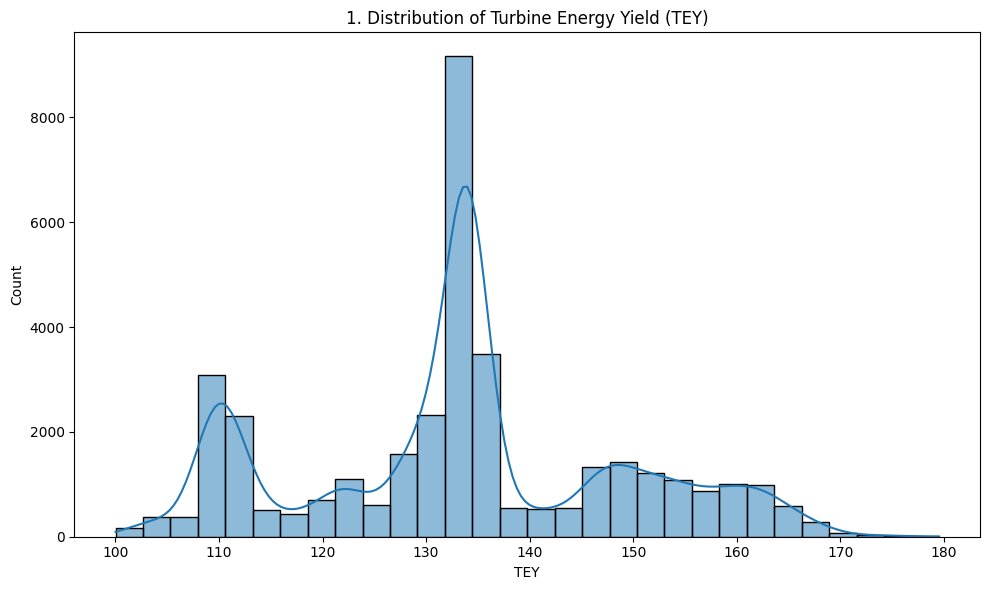

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['TEY'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Turbine Energy Yield (TEY)')
show_fig()
plot_no += 1

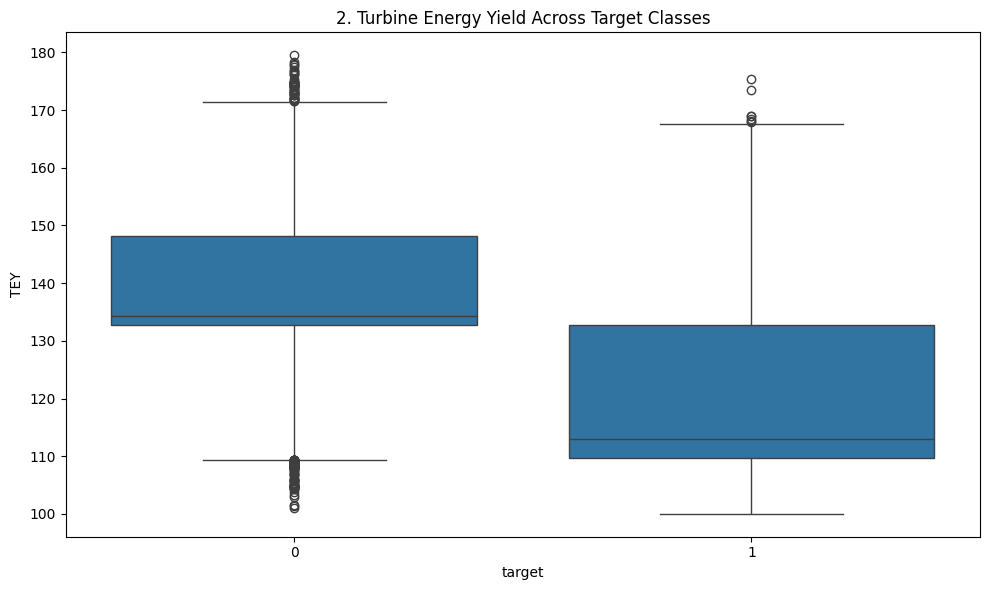

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='TEY', data=df)
plt.title(f'{plot_no}. Turbine Energy Yield Across Target Classes')
show_fig()
plot_no += 1

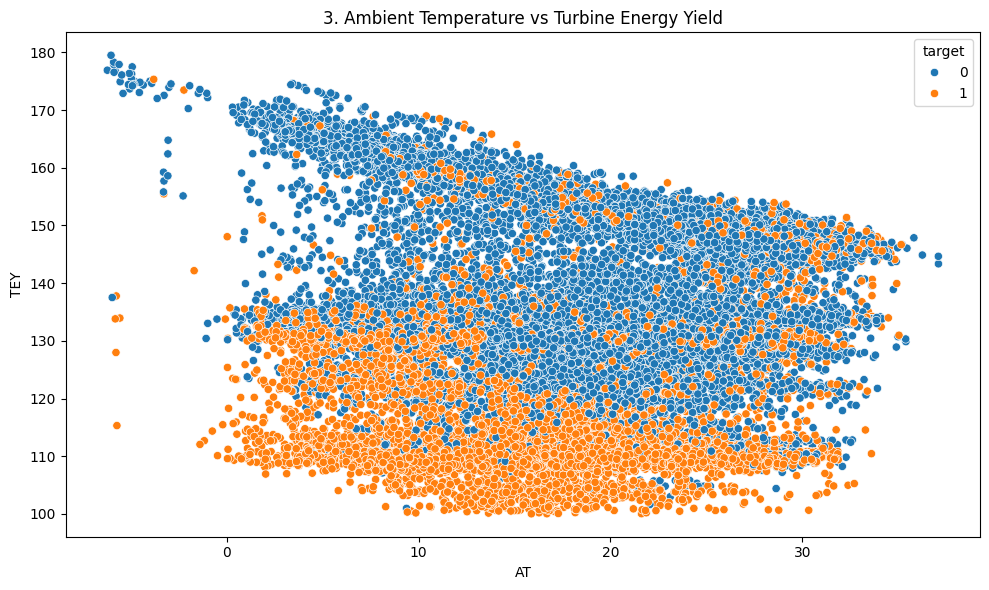

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AT', y='TEY', hue='target')
plt.title(f'{plot_no}. Ambient Temperature vs Turbine Energy Yield')
show_fig()
plot_no += 1

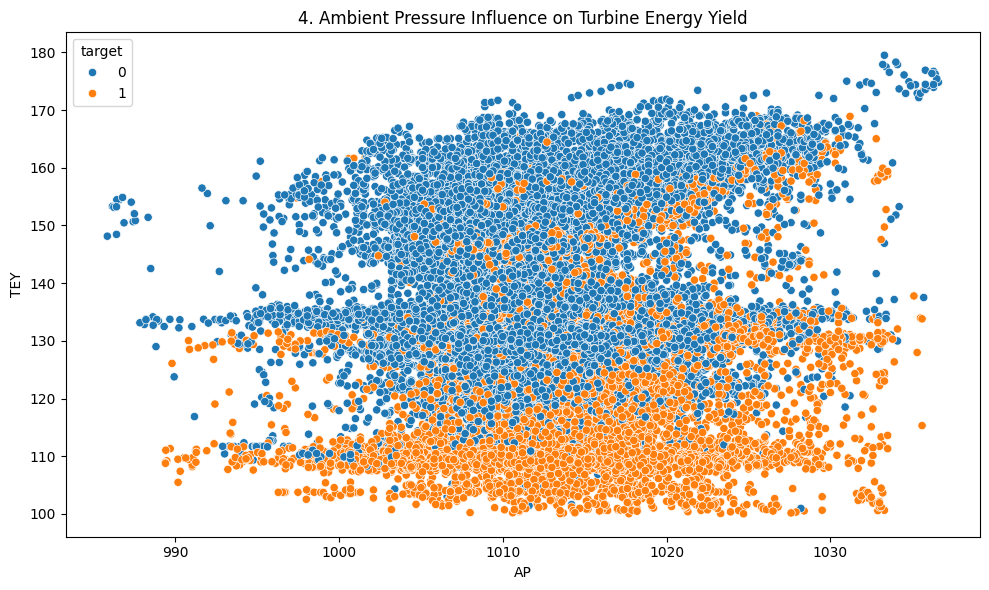

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AP', y='TEY', hue='target')
plt.title(f'{plot_no}. Ambient Pressure Influence on Turbine Energy Yield')
show_fig()
plot_no += 1

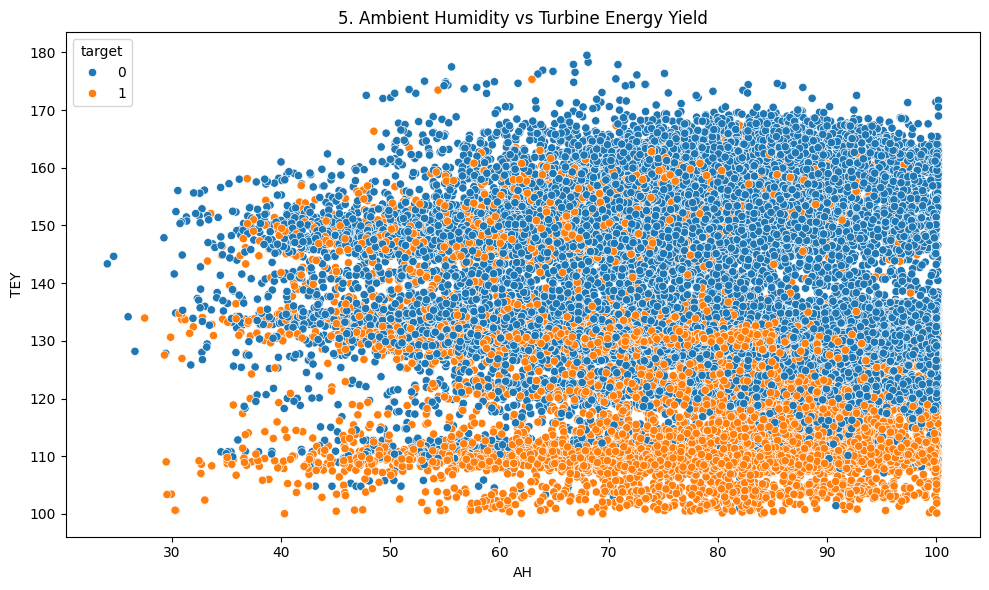

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AH', y='TEY', hue='target')
plt.title(f'{plot_no}. Ambient Humidity vs Turbine Energy Yield')
show_fig()
plot_no += 1

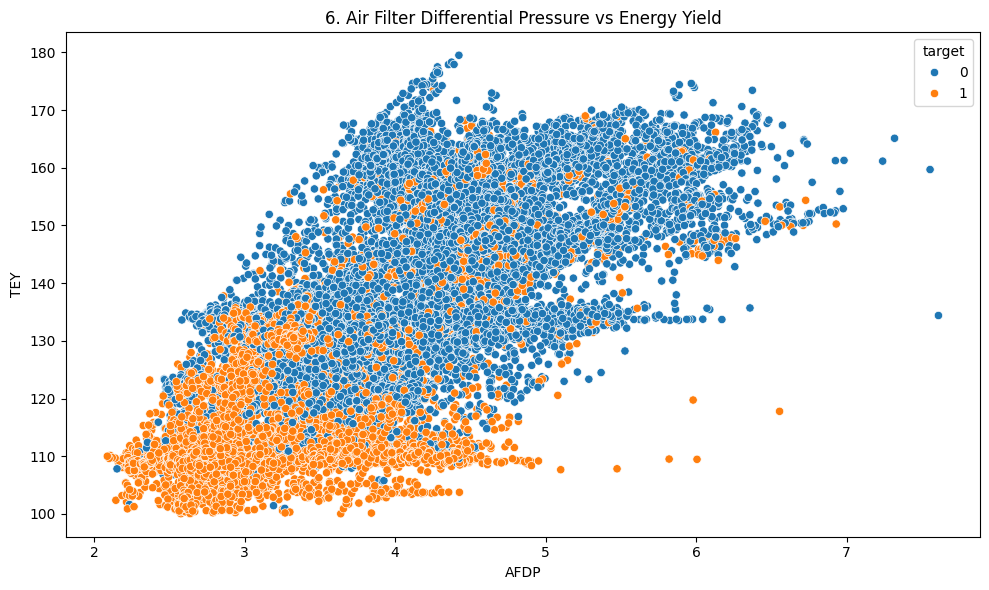

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AFDP', y='TEY', hue='target')
plt.title(f'{plot_no}. Air Filter Differential Pressure vs Energy Yield')
show_fig()
plot_no += 1

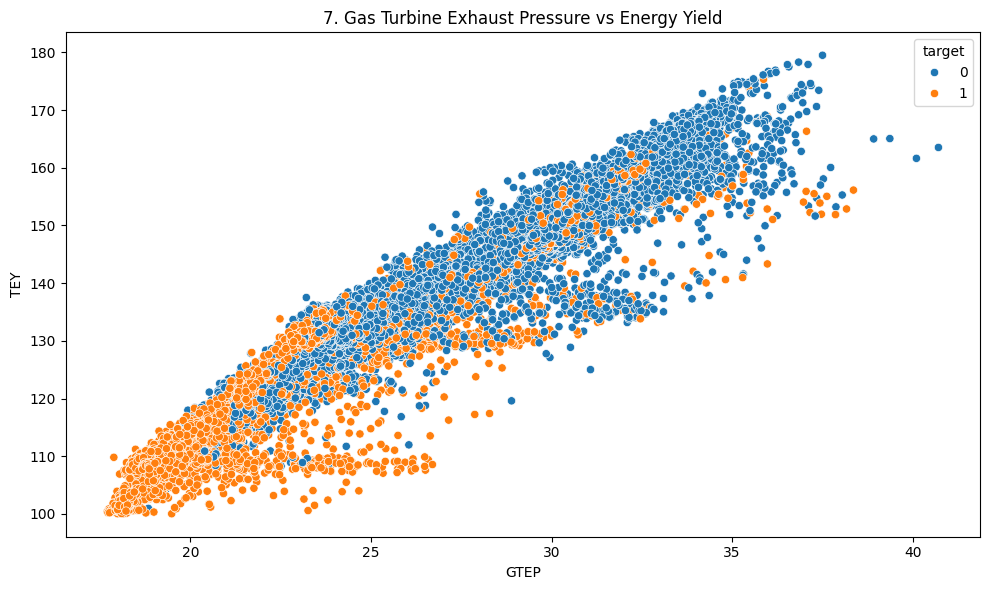

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='GTEP', y='TEY', hue='target')
plt.title(f'{plot_no}. Gas Turbine Exhaust Pressure vs Energy Yield')
show_fig()
plot_no += 1

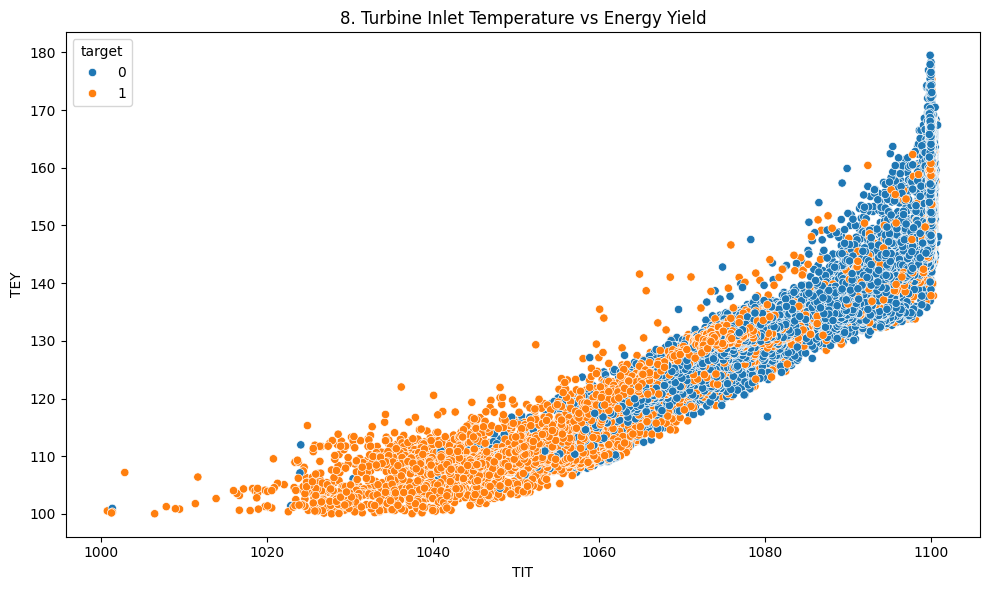

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TIT', y='TEY', hue='target')
plt.title(f'{plot_no}. Turbine Inlet Temperature vs Energy Yield')
show_fig()
plot_no += 1

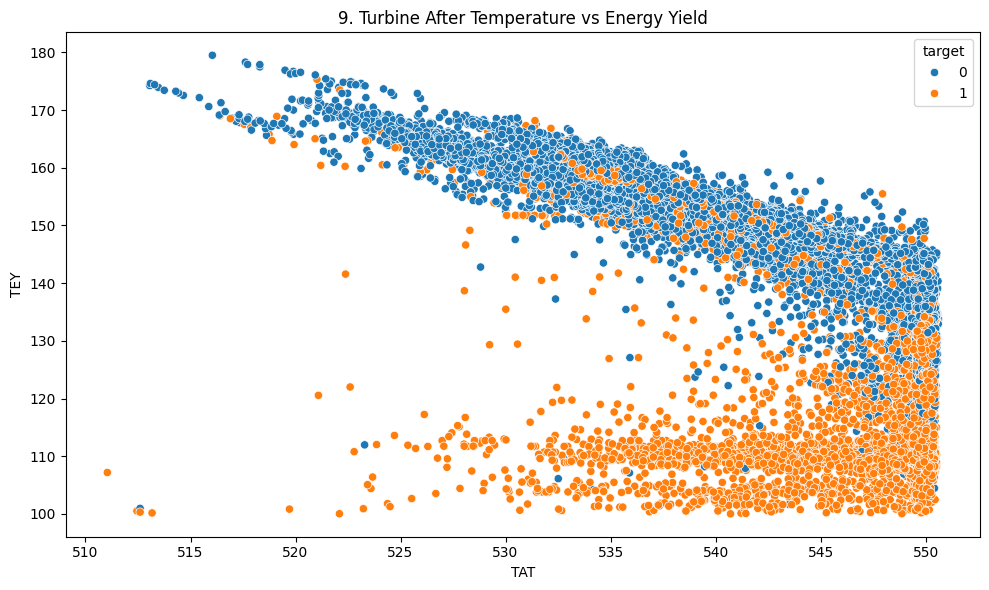

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='TAT', y='TEY', hue='target')
plt.title(f'{plot_no}. Turbine After Temperature vs Energy Yield')
show_fig()
plot_no += 1

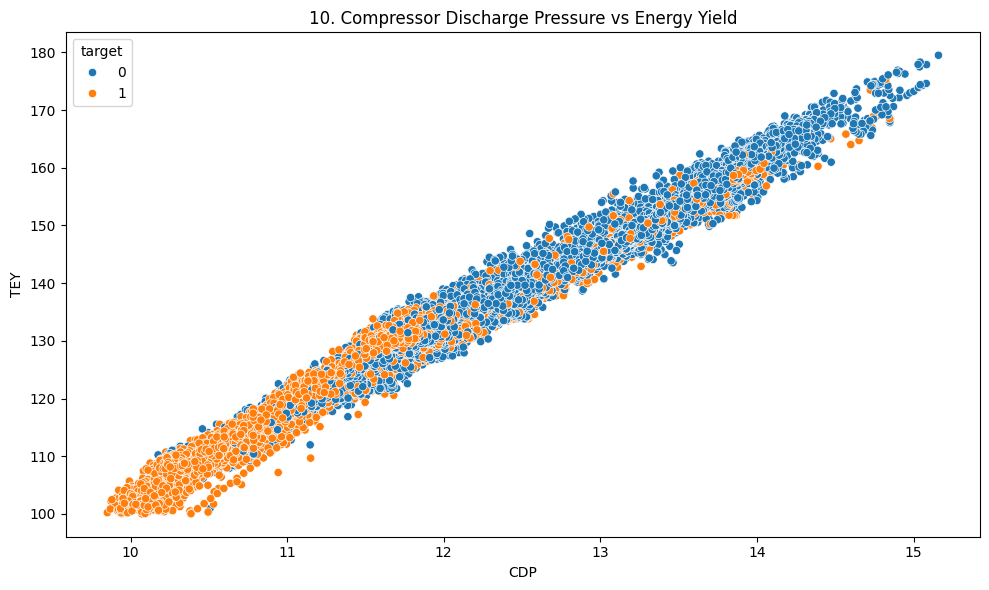

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CDP', y='TEY', hue='target')
plt.title(f'{plot_no}. Compressor Discharge Pressure vs Energy Yield')
show_fig()
plot_no += 1

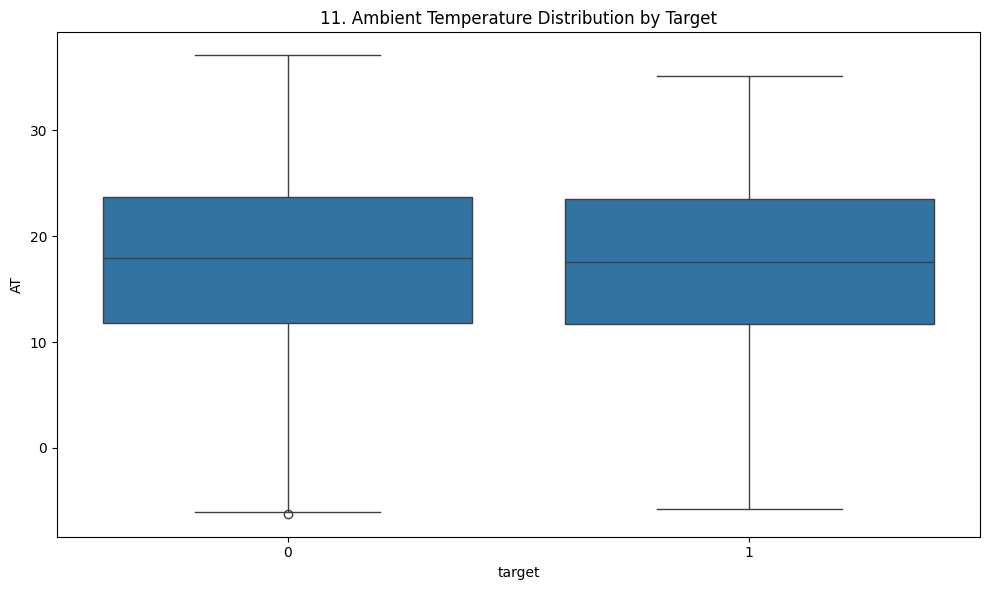

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='AT', data=df)
plt.title(f'{plot_no}. Ambient Temperature Distribution by Target')
show_fig()
plot_no += 1

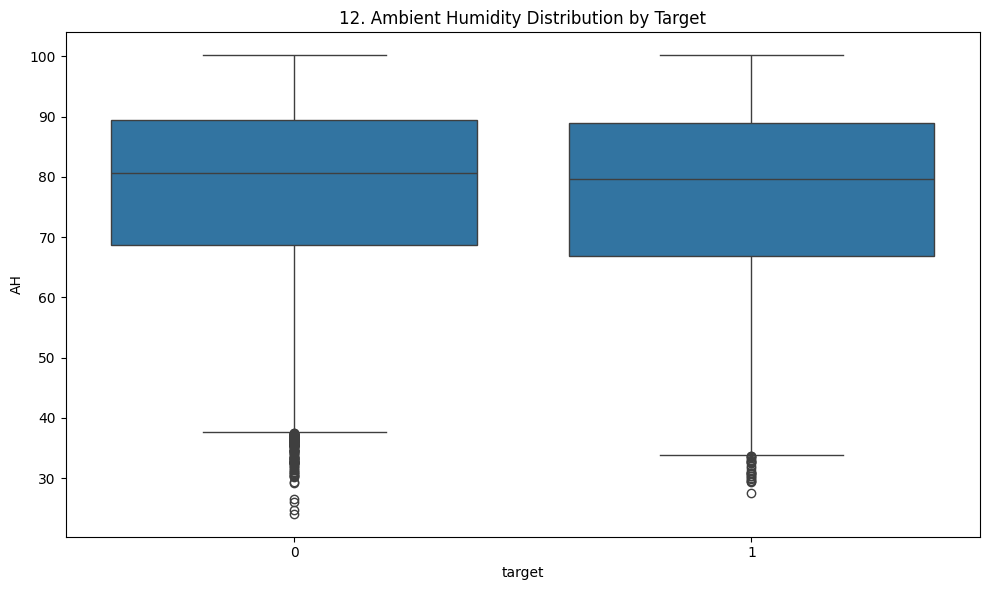

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='AH', data=df)
plt.title(f'{plot_no}. Ambient Humidity Distribution by Target')
show_fig()
plot_no += 1

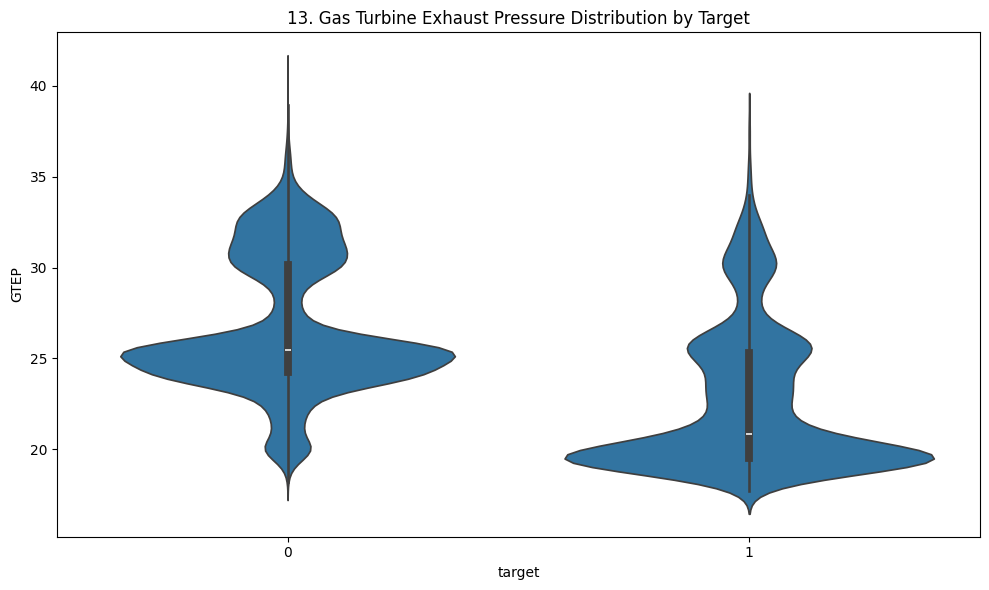

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='target', y='GTEP', data=df)
plt.title(f'{plot_no}. Gas Turbine Exhaust Pressure Distribution by Target')
show_fig()
plot_no += 1

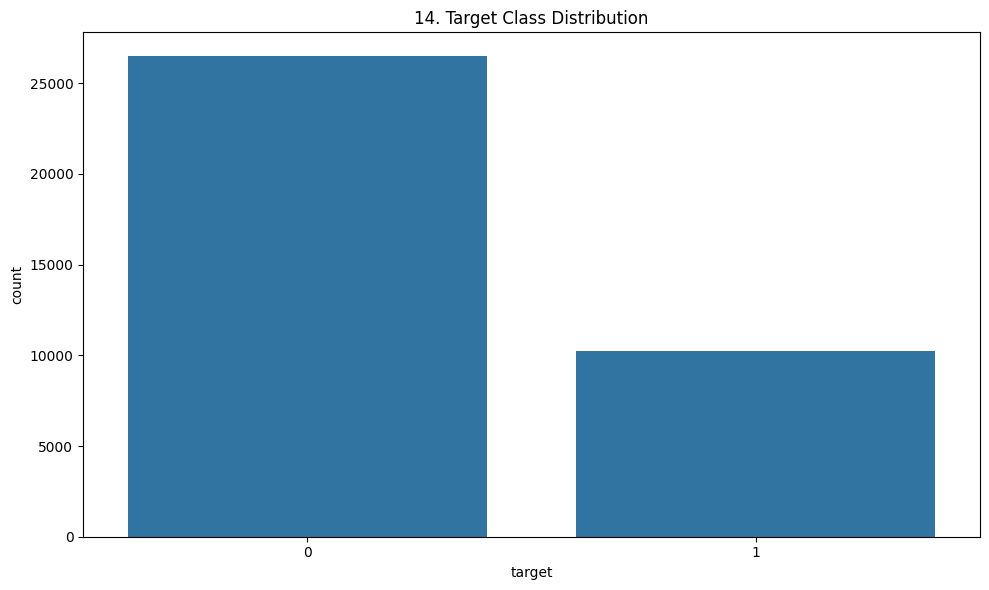

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='target')
plt.title(f'{plot_no}. Target Class Distribution')
show_fig()
plot_no += 1

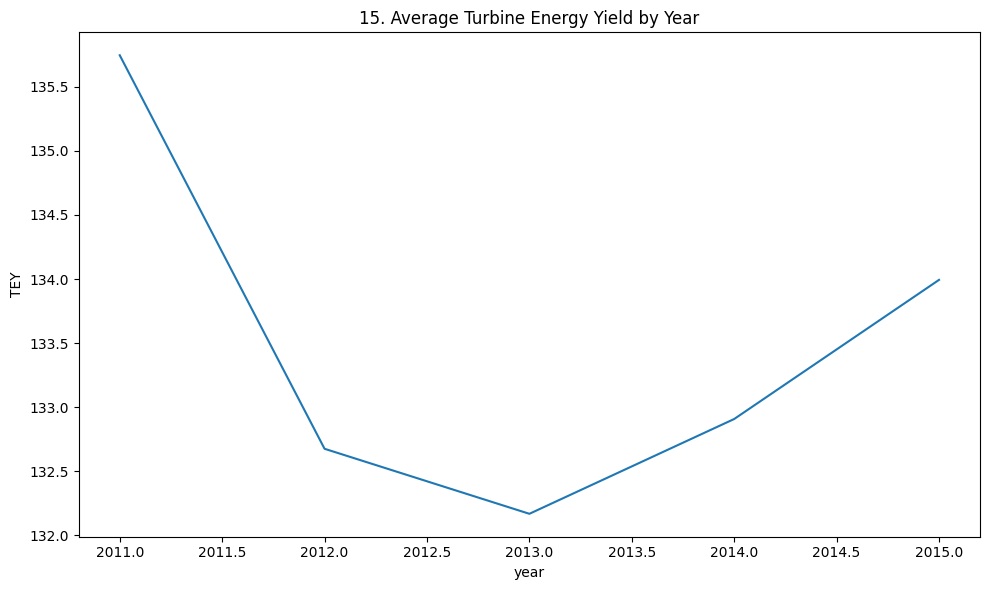

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.sort_values('year'), x='year', y='TEY', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Turbine Energy Yield by Year')
show_fig()
plot_no += 1

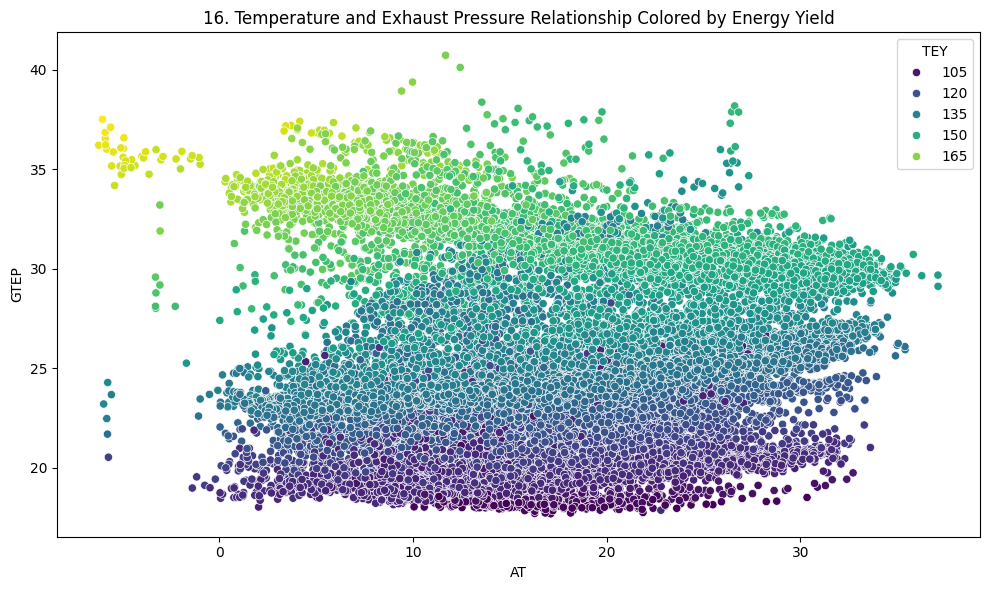

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='AT', y='GTEP', hue='TEY', palette='viridis')
plt.title(f'{plot_no}. Temperature and Exhaust Pressure Relationship Colored by Energy Yield')
show_fig()
plot_no += 1

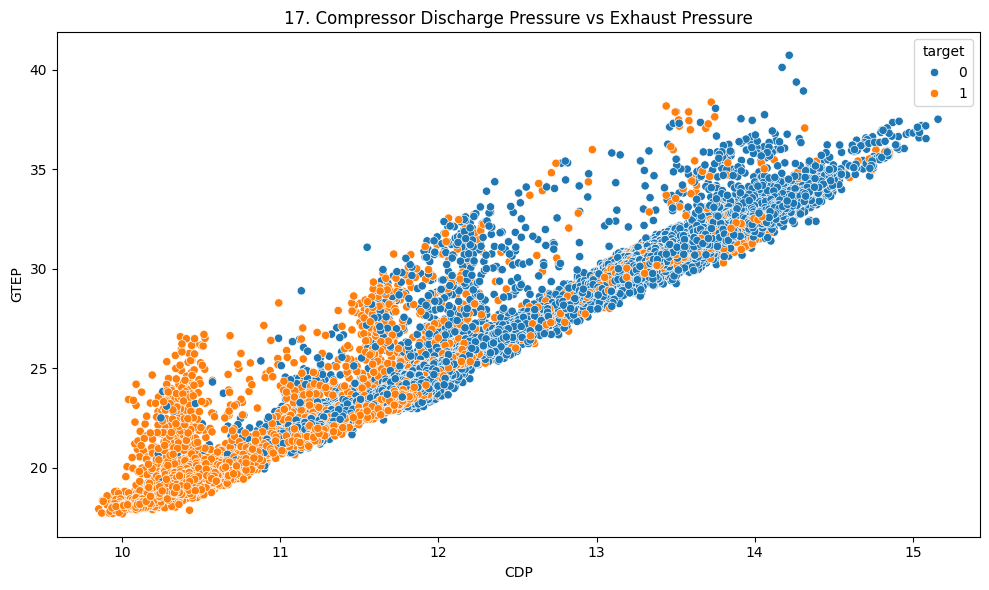

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CDP', y='GTEP', hue='target')
plt.title(f'{plot_no}. Compressor Discharge Pressure vs Exhaust Pressure')
show_fig()
plot_no += 1

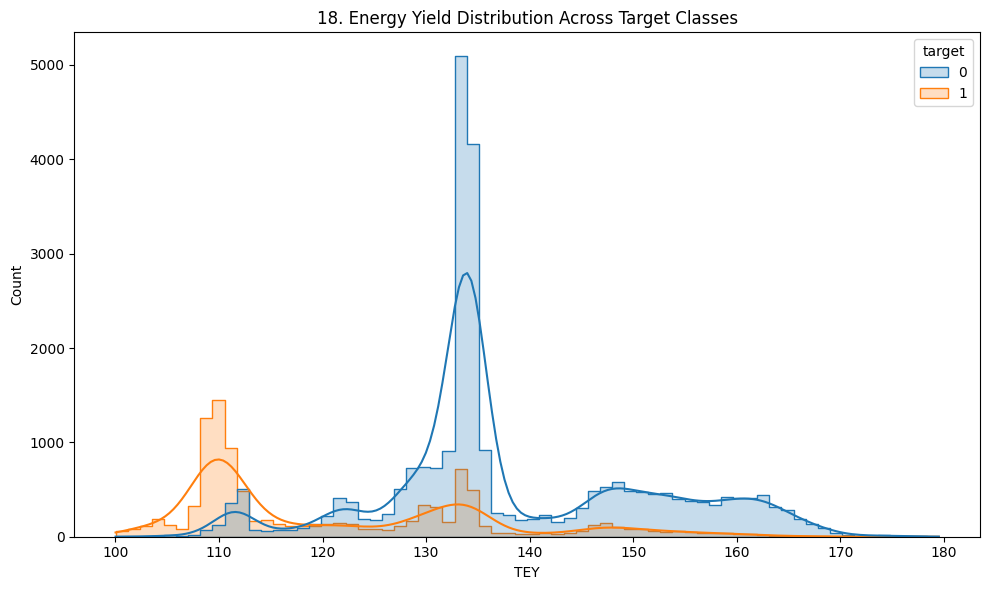

In [30]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='TEY', hue='target', kde=True, element='step')
plt.title(f'{plot_no}. Energy Yield Distribution Across Target Classes')
show_fig()
plot_no += 1

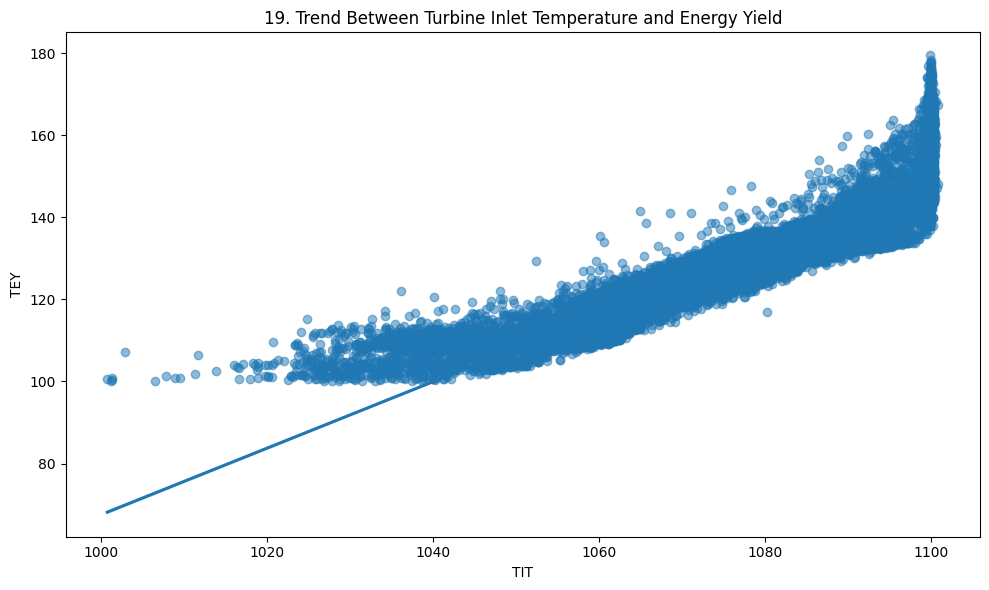

In [31]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='TIT', y='TEY', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Trend Between Turbine Inlet Temperature and Energy Yield')
show_fig()
plot_no += 1

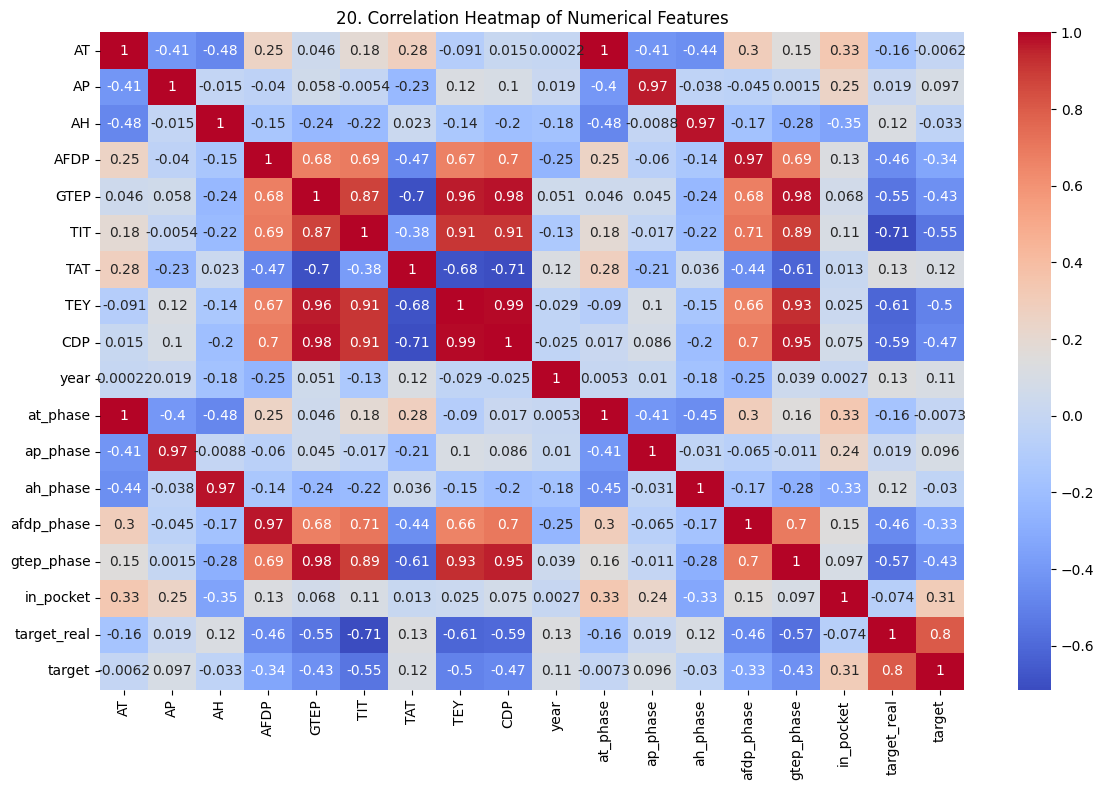

In [32]:
fig = plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Select input features and target

In [33]:
X = df.drop(columns=['target', 'target_real'])
y = df['target']

## Split dataset into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create SVM classification pipeline with feature scaling

In [35]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

## Train the model

In [36]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(random_state=42))])

## Make predictions

In [37]:
y_pred = model.predict(X_test)

## Calculate and print accuracy

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

Accuracy Score: 0.8872


## Display confusion matrix

<Figure size 700x600 with 0 Axes>

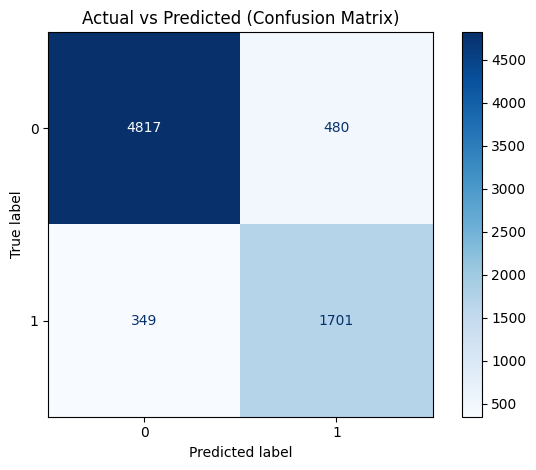

In [39]:
fig = plt.figure(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    values_format='d'
)
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()